In [34]:
import tensorflow as tf
from tensorflow import keras 
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

In [35]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

In [36]:
X_train.shape

(60000, 28, 28)

In [37]:
X_train = X_train / 255
X_test = X_test / 255

In [38]:
X_train_flattened = X_train.reshape(len(X_train),28*28)
X_test_flattened = X_test.reshape(len(X_test), 28 * 28)
X_train_flattened.shape

(60000, 784)

In [39]:
X_train_flattened[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [40]:
model = keras.Sequential([
    keras.layers.Dense(10, input_shape=(784,), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics =['accuracy']
)

model.fit(X_train_flattened, y_train, epochs=5)

c:\Users\boogey\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8779 - loss: 0.4674
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9154 - loss: 0.3032
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9208 - loss: 0.2833
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9237 - loss: 0.2732
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9254 - loss: 0.2662


In [41]:
model.evaluate(X_test_flattened,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9254 - loss: 0.2692


[0.2691761553287506, 0.9254000186920166]

In [42]:
prediction = model.predict(X_test_flattened[0:1])
predicted_digit = np.argmax(prediction[0])

print("Predicted digit:", predicted_digit)
print("Actual digit:", y_test[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step
Predicted digit: 7
Actual digit: 7


In [43]:
prediction = model.predict(X_test_flattened)
prediction_labels = [np.argmax(i) for i in prediction]
prediction_labels[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4)]

In [44]:
cm =  tf.math.confusion_matrix(labels=y_test, predictions= prediction_labels)
cm

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 965,    0,    2,    2,    0,    6,    2,    2,    1,    0],
       [   0, 1113,    5,    1,    0,    1,    3,    2,   10,    0],
       [   5,    9,  928,   16,   10,    3,   10,   11,   38,    2],
       [   3,    0,   21,  914,    1,   29,    1,   12,   23,    6],
       [   2,    1,    6,    2,  924,    0,    5,    4,    9,   29],
       [  11,    3,    8,   30,   11,  777,    6,    8,   31,    7],
       [  16,    3,   11,    1,    9,   20,  892,    2,    4,    0],
       [   1,    6,   25,    6,    7,    0,    0,  952,    3,   28],
       [   7,    9,    6,   18,    9,   23,    7,   12,  877,    6],
       [  11,    7,    1,   10,   30,    6,    0,   26,    6,  912]],
      dtype=int32)>

Text(95.83333333333333, 0.5, 'Truth')

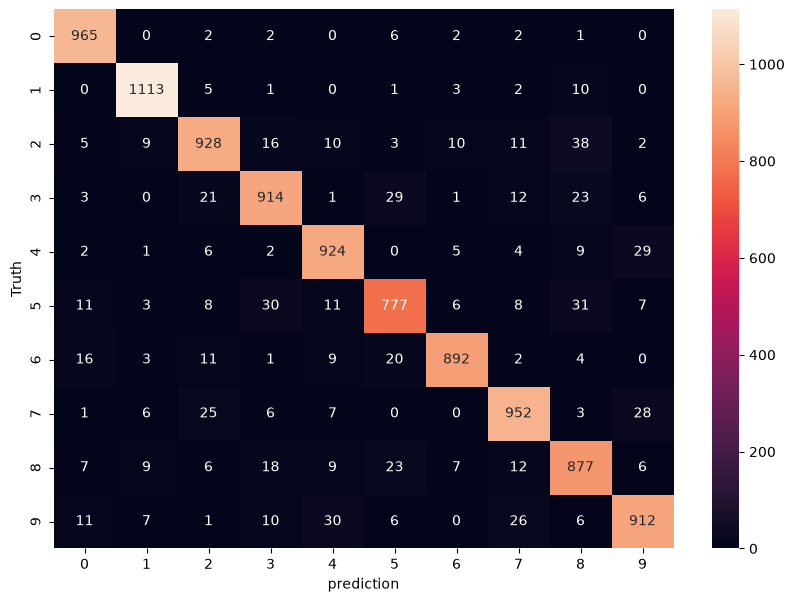

In [45]:
import seaborn as sn
plt.figure(figsize=(10,7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('prediction')
plt.ylabel('Truth')

In [46]:
model = keras.Sequential([
    keras.layers.Dense(100, input_shape=(784,), activation = 'relu'),
    keras.layers.Dense(10, activation = 'sigmoid')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(X_train_flattened, y_train, epochs=5)

c:\Users\boogey\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.9223 - loss: 0.2740
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9629 - loss: 0.1267
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9732 - loss: 0.0900
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9786 - loss: 0.0684
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9838 - loss: 0.0528


Text(95.83333333333333, 0.5, 'Truth')

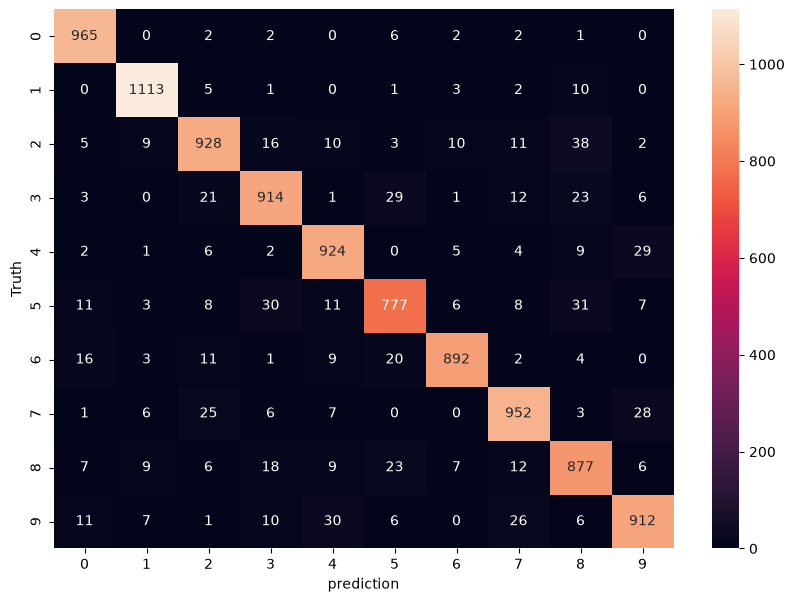

In [47]:
import seaborn as sn
plt.figure(figsize=(10,7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('prediction')
plt.ylabel('Truth')